# Importação

In [ ]:
!pip install rnanorm

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from rnanorm import TMM

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df_xena = pd.read_csv('/content/drive/MyDrive/cancer-BRCA/datasets/TCGA-BRCA.star_counts.tsv.gz', sep='\t')

print(df_xena.shape)
df_xena.head()

(60660, 1227)


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,11.737670,9.781360,13.122504,11.016808,11.000000,9.614710,11.092096,12.103616,12.417325,...,10.747354,10.360847,10.675957,11.337064,11.697836,12.339850,12.131857,8.974415,13.326289,9.710806
1,ENSG00000000005.6,7.721099,3.321928,0.000000,6.686501,3.807355,4.087463,5.392317,3.000000,3.321928,...,1.584963,2.000000,1.000000,8.164907,0.000000,2.807355,3.906891,3.700440,3.807355,1.000000
2,ENSG00000000419.13,11.042343,11.357552,11.506308,10.801708,11.074141,11.107217,10.318543,11.160502,11.072803,...,10.429407,10.811375,10.835261,10.693487,11.922213,11.221587,10.913637,11.659550,10.962173,12.416270
3,ENSG00000000457.14,11.036860,10.754888,12.218260,11.190442,10.857981,8.539159,11.527966,10.635718,9.945444,...,10.366322,10.558421,11.262682,10.751544,10.607330,10.163650,10.575539,11.929258,11.403012,10.870365
4,ENSG00000000460.17,9.131857,8.721099,10.973697,10.761551,9.550747,8.550747,9.177420,9.727920,10.504819,...,8.661778,9.000000,9.794416,9.231221,9.782998,9.252665,8.632995,10.562242,10.060696,9.722808


Podemos identificar as **amostras tumorais** e **amostras controle** com base no código do identificador (ID):
* **Códigos de 01 a 09:** São amostras de **Tumor** (geralmente `01` para Tumor Sólido Primário).
* **Códigos de 10 a 19:** São amostras de **Controle/Normal** (geralmente `11` para Tecido Normal Adjacente).

In [4]:
sample_info = pd.DataFrame(index=df_xena.columns[1:])

# Puxando os últimos dígitos do ID, que servem como o identificador
sample_info['code'] = sample_info.index.str[13:15]
sample_info['condition'] = sample_info['code'].apply(lambda x: 'Tumor' if int(x) < 10 else 'Normal')

sample_info.head()

,code,condition
TCGA-D8-A146-01A,01,Tumor
TCGA-AQ-A0Y5-01A,01,Tumor
TCGA-C8-A274-01A,01,Tumor
TCGA-BH-A0BD-01A,01,Tumor
TCGA-B6-A1KC-01B,01,Tumor


No Xena Browser, local de onde retiramos a matriz de contagem dos genes, é comum que a unidade de medida esteja normalizada.

Para começarmos a análise, precisamos então aplicar a transformação reversa.

In [5]:
x_norm = df_xena.iloc[:, 1:]

x_raw = 2**x_norm - 1

# Arredondando valores flutuantes e transformando em inteiros
counts = x_raw.round().astype(int)

# Garantindo que não existam valores negativos
counts[counts < 0] = 0

# Filtragem de Ruído



*   Desconsideraremos  genes cuja soma da contagem sejam irrelevantes, exigindo ao menos 10 reads em pelo menos 50 amostras



In [6]:
n_genes = counts.shape[0]

genes_to_keep = (counts >= 10).sum(axis=1) >=50
counts = counts[genes_to_keep]

n_filtered = n_genes - counts.shape[0]
print('Número de genes filtrados:', n_filtered)

Número de genes filtrados: 31403


In [7]:
del df_xena, x_norm, x_raw

# Análise Exploratória de Dados

## Profundidade de Sequenciamento
<font size=3>

*   A soma total de reads de uma amostra é chamada de library_size.
*   Se a amostra A tem 10 milhões de reads, e a B 20 milhões, é esperado que todos os genes na amostra B tenham o dobro da contagem.

A profundidade de sequenciamento representa o total de fragmentos de RNA (reads) capturados de uma amostra. Portanto, uma contagem muito baixa indica que o processo técnico falhou, resultando em uma "fotografia" desfocada e incompleta da atividade celular.
Se mantivermos essas amostras deficientes na análise, corremos o risco de concluir erroneamente que certos genes estão "desligados" ou subexpressos.



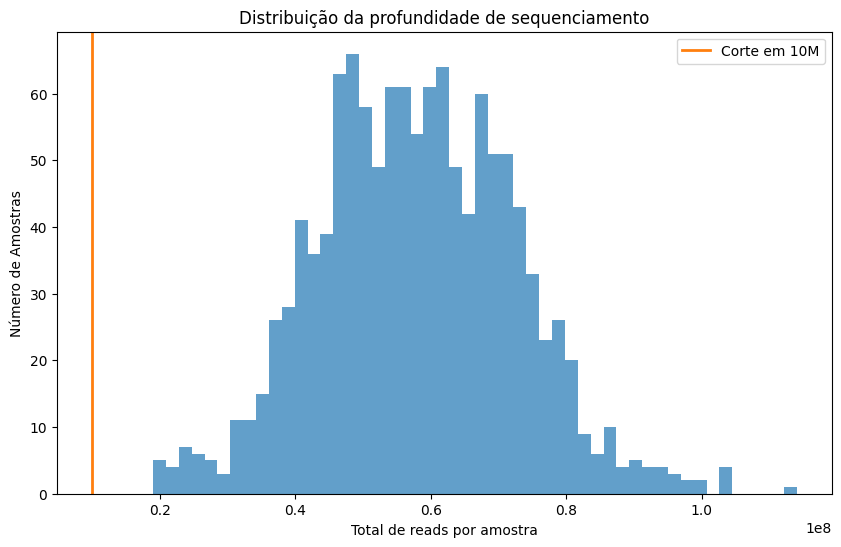


Estatísticas de Profundidade:
Média: 57,968,336 reads
Mediana: 57,606,637 reads
Mínimo: 18,997,896 reads
Máximo: 113,990,943 reads

Amostras abaixo de 10M reads: 0


In [8]:
library_sizes = counts.sum(axis=0)

threshold = 10_000_000

plt.figure(figsize=(10, 6))

plt.hist(library_sizes, bins=50, alpha=0.7)
plt.axvline(threshold, color='tab:orange', lw=2, label=f'Corte em 10M')
plt.title('Distribuição da profundidade de sequenciamento')
plt.xlabel('Total de reads por amostra')
plt.ylabel('Número de Amostras')
plt.legend()
plt.show()

print(f"\nEstatísticas de Profundidade:")
print(f"Média: {library_sizes.mean():,.0f} reads")
print(f"Mediana: {library_sizes.median():,.0f} reads")
print(f"Mínimo: {library_sizes.min():,.0f} reads")
print(f"Máximo: {library_sizes.max():,.0f} reads")

# identificando amostras problemáticas
bad_samples = library_sizes[library_sizes < threshold]
print(f"\nAmostras abaixo de 10M reads: {len(bad_samples)}")

## Distribuição dos Genes
<font size=3>



Em biologia molecular, dados de contagem seguem uma distribuição Binomial Negativa ou Zipfiana:
> *Pouquíssimos genes têm contagens gigantescas, e a grande maioria tem contagens baixas ou zero.*

Se tentarmos visualizar os dados brutos, não veremos nada além de uma barra no zero. Para enxergar a biologia, precisamos aplicar uma escala logarítmica

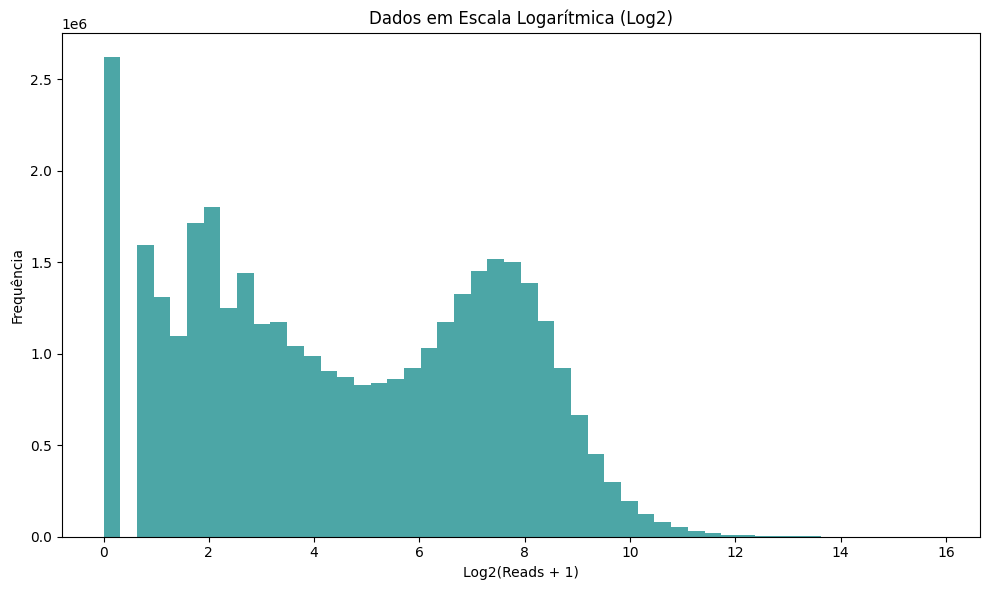

In [11]:
plt.figure(figsize=(10, 6))

sample_data = counts.values.flatten()
log_counts = np.log1p(sample_data)

plt.hist(log_counts, bins=50, color='teal', alpha=0.7)
plt.title('Dados em Escala Logarítmica (Log2)')
plt.xlabel('Log2(Reads + 1)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

## Similaridade e Correlação

Subconjunto criado para a correlação: (1000, 1226)


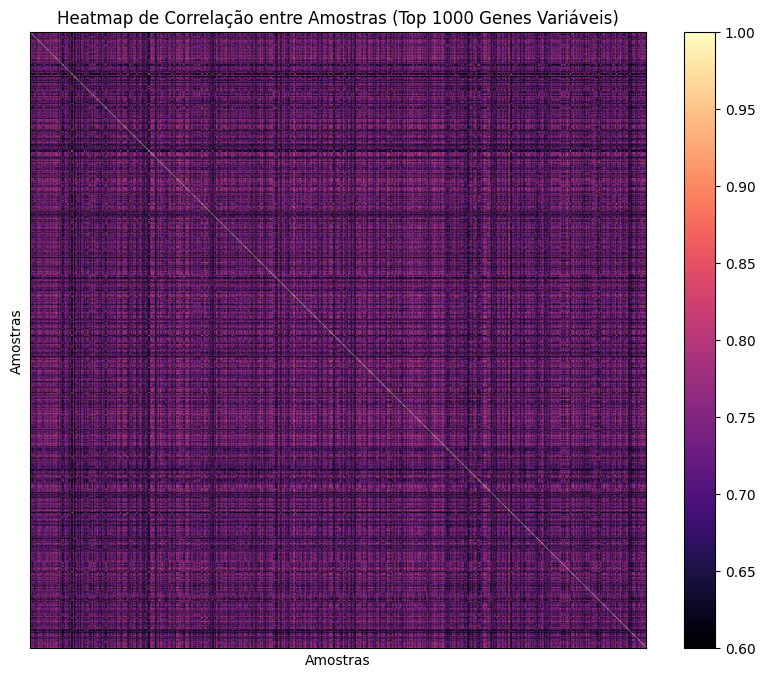

In [12]:
variances = counts.var(axis=1)

top_genes_ids = variances.nlargest(1000).index
counts_subset = counts.loc[top_genes_ids]

print("Subconjunto criado para a correlação:", counts_subset.shape)

corr_matrix = counts_subset.corr(method='spearman')

plt.figure(figsize=(10, 8))
plt.title('Heatmap de Correlação entre Amostras (Top 1000 Genes Variáveis)')
plt.imshow(corr_matrix, vmin=0.6, vmax=1.0, cmap='magma')
plt.xlabel('Amostras')
plt.ylabel('Amostras')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

* **Blocos Quadrados:** Se você vir quadrados bem definidos de cores claras ao longo da diagonal, isso sugere grupos de amostras muito parecidas.
* **Homogeneidade:** Se tudo for muito parecido, indica que a biologia do tecido é consistente.
* **Outliers:** Linhas escuras (roxo/preto) indicam amostras que não se parecem com as outras e podem ser erros técnicos.

# Normalização

In [13]:
tmm_model = TMM()

tmm_counts = tmm_model.fit_transform(counts.T)

tmm_counts = tmm_counts.T

log_tmm = np.log2(tmm_counts + 1)

print(f'Dimensão da matriz logTMM: {log_tmm.shape}\n')

log_tmm

Dimensão da matriz logTMM: (29257, 1226)



array([[5.70465275, 4.0488639 , 7.00479526, ..., 2.8279565 , 7.08190876,
        3.94607047],
       [2.05187216, 0.21316348, 0.        , ..., 0.19639668, 0.22678545,
        0.0246314 ],
       [5.02610216, 5.5669951 , 5.41129222, ..., 5.33277839, 4.76074442,
        6.57146467],
       ...,
       [2.41821143, 3.86489971, 3.91143422, ..., 4.20375184, 3.4820988 ,
        2.64034525],
       [0.12419339, 0.14554904, 0.26311074, ..., 0.06847954, 0.28995413,
        0.18619388],
       [0.53554637, 0.72648347, 0.34654819, ..., 0.95290095, 0.35047258,
        0.33147188]])

# Redução de Dimensionalidade

In [14]:
scaler = StandardScaler()

log_tmm_scaled = scaler.fit_transform(log_tmm.T)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(log_tmm_scaled)

print('Dimensão original dos dados:', log_tmm.shape)
print('Dados após PCA', X_pca.T.shape)

Dimensão original dos dados: (29257, 1226)
Dados após PCA (2, 1226)


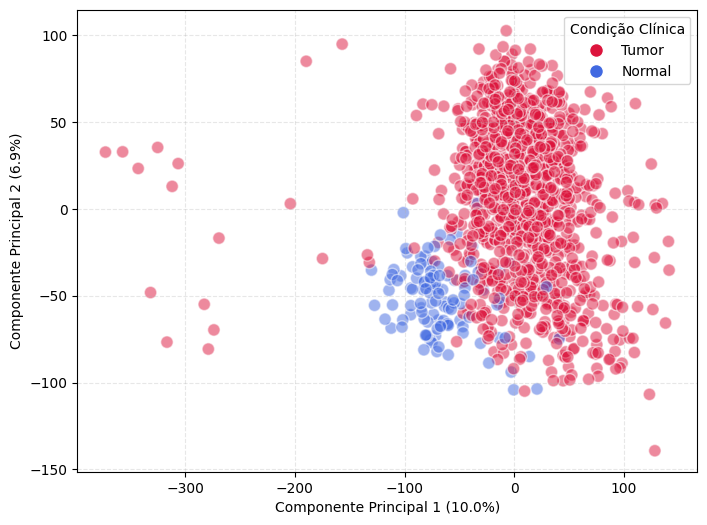

In [15]:
plt.figure(figsize=(8, 6))

colors = np.where(sample_info["condition"].to_numpy() == "Tumor", "crimson", "royalblue")

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=80, edgecolor='white')

plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

legend = [Line2D([0], [0], marker='o', color='w', label='Tumor', markerfacecolor='crimson', markersize=10),
          Line2D([0], [0], marker='o', color='w', label='Normal', markerfacecolor='royalblue', markersize=10)]

plt.legend(handles=legend, title="Condição Clínica", loc="best")

plt.grid(ls="--", alpha=0.3)
plt.show()